# Notebook 02 ” BERT Sentiment & Crisis Classifier
## Crisis Alert System Â· DistilBERT fine-tuned on Disaster Tweets

**Goal:** Fine-tune `distilbert-base-uncased` for binary crisis detection, validate performance, and confirm the model outputs a calibrated 0.0“1.0 crisis probability score for the ensemble.

In [1]:
import os
# Force transformers to use PyTorch only — avoids tf_keras import error
os.environ["USE_TF"] = "0"
os.environ["USE_JAX"] = "0"

from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
CRISIS_COLOR = "#e63946"
NORMAL_COLOR = "#457b9d"

print("Imports OK")


Imports OK


## 1. Train DistilBERT

In [2]:
from src.models.bert_classifier import BERTClassifier

clf = BERTClassifier()
result = clf.train(
    data_path  = "../data/processed/tweets_clean.csv",
    epochs     = 3,
    batch_size = 16,
    output_dir = "../outputs/models/bert_v1",
)
print("Training complete:", result)

Train: 6471 | Val: 1142


/home/jalzate/anaconda3/lib/python3.13/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1215 [00:00<?, ?it/s]

{'loss': 0.5586, 'grad_norm': 5.246095180511475, 'learning_rate': 4.794238683127572e-05, 'epoch': 0.12}
{'loss': 0.4815, 'grad_norm': 6.553736209869385, 'learning_rate': 4.5884773662551446e-05, 'epoch': 0.25}
{'loss': 0.4397, 'grad_norm': 4.983395099639893, 'learning_rate': 4.3827160493827164e-05, 'epoch': 0.37}
{'loss': 0.4454, 'grad_norm': 5.627674102783203, 'learning_rate': 4.176954732510288e-05, 'epoch': 0.49}
{'loss': 0.438, 'grad_norm': 4.88943338394165, 'learning_rate': 3.971193415637861e-05, 'epoch': 0.62}
{'loss': 0.46, 'grad_norm': 4.717456340789795, 'learning_rate': 3.7654320987654326e-05, 'epoch': 0.74}
{'loss': 0.4269, 'grad_norm': 5.459303379058838, 'learning_rate': 3.5596707818930044e-05, 'epoch': 0.86}
{'loss': 0.3832, 'grad_norm': 4.452291011810303, 'learning_rate': 3.353909465020576e-05, 'epoch': 0.99}


  0%|          | 0/36 [00:00<?, ?it/s]

{'eval_loss': 0.4182797074317932, 'eval_f1': 0.8070866141732284, 'eval_runtime': 1.8183, 'eval_samples_per_second': 628.069, 'eval_steps_per_second': 19.799, 'epoch': 1.0}
{'loss': 0.3108, 'grad_norm': 3.463111162185669, 'learning_rate': 3.148148148148148e-05, 'epoch': 1.11}
{'loss': 0.3227, 'grad_norm': 4.07728910446167, 'learning_rate': 2.9423868312757202e-05, 'epoch': 1.23}
{'loss': 0.3227, 'grad_norm': 2.934812545776367, 'learning_rate': 2.736625514403292e-05, 'epoch': 1.36}
{'loss': 0.2924, 'grad_norm': 2.7618062496185303, 'learning_rate': 2.5308641975308646e-05, 'epoch': 1.48}
{'loss': 0.3476, 'grad_norm': 6.7887678146362305, 'learning_rate': 2.3251028806584364e-05, 'epoch': 1.6}
{'loss': 0.3059, 'grad_norm': 5.810543060302734, 'learning_rate': 2.1193415637860082e-05, 'epoch': 1.73}
{'loss': 0.3121, 'grad_norm': 4.3346734046936035, 'learning_rate': 1.91358024691358e-05, 'epoch': 1.85}
{'loss': 0.2972, 'grad_norm': 2.004450798034668, 'learning_rate': 1.7078189300411522e-05, 'epoch

  0%|          | 0/36 [00:00<?, ?it/s]

{'eval_loss': 0.4034078121185303, 'eval_f1': 0.8205645161290323, 'eval_runtime': 1.8075, 'eval_samples_per_second': 631.799, 'eval_steps_per_second': 19.917, 'epoch': 2.0}
{'loss': 0.2135, 'grad_norm': 3.891354560852051, 'learning_rate': 1.5020576131687244e-05, 'epoch': 2.1}
{'loss': 0.237, 'grad_norm': 4.434360027313232, 'learning_rate': 1.2962962962962962e-05, 'epoch': 2.22}
{'loss': 0.2156, 'grad_norm': 6.944966793060303, 'learning_rate': 1.0905349794238684e-05, 'epoch': 2.35}
{'loss': 0.1987, 'grad_norm': 4.849970817565918, 'learning_rate': 8.847736625514404e-06, 'epoch': 2.47}
{'loss': 0.192, 'grad_norm': 4.043283462524414, 'learning_rate': 6.790123456790123e-06, 'epoch': 2.59}
{'loss': 0.2109, 'grad_norm': 0.23511065542697906, 'learning_rate': 4.732510288065844e-06, 'epoch': 2.72}
{'loss': 0.202, 'grad_norm': 7.655959129333496, 'learning_rate': 2.6748971193415637e-06, 'epoch': 2.84}
{'loss': 0.1841, 'grad_norm': 7.14066743850708, 'learning_rate': 6.17283950617284e-07, 'epoch': 2.

  0%|          | 0/36 [00:00<?, ?it/s]

{'eval_loss': 0.48510318994522095, 'eval_f1': 0.8045501551189245, 'eval_runtime': 1.6212, 'eval_samples_per_second': 704.437, 'eval_steps_per_second': 22.206, 'epoch': 3.0}
{'train_runtime': 98.5025, 'train_samples_per_second': 197.081, 'train_steps_per_second': 12.335, 'train_loss': 0.32281100642043375, 'epoch': 3.0}

              precision    recall  f1-score   support

      Normal       0.87      0.86      0.86       651
      Crisis       0.81      0.83      0.82       491

    accuracy                           0.84      1142
   macro avg       0.84      0.84      0.84      1142
weighted avg       0.84      0.84      0.84      1142

Model saved to ../outputs/models/bert_v1
Training complete: {'val_size': 1142, 'model_dir': '../outputs/models/bert_v1'}


## 2. Load & Sanity-Check Predictions

In [3]:
clf = BERTClassifier.load("../outputs/models/bert_v1")

examples = [
    ("Massive wildfire destroys thousands of homes, evacuation ordered",      1),
    ("Oil spill reported near Gulf coast, marine life at risk",                1),
    ("Earthquake 6.2 magnitude hits city, buildings collapsed",                1),
    ("I just had the best pizza of my life, absolutely amazing!",              0),
    ("Looking forward to the weekend, so much to do",                          0),
    ("The new season of my favourite show drops tonight",                      0),
]

texts  = [t for t, _ in examples]
truth  = [l for _, l in examples]
scores = clf.predict(texts)

print(f"{'Crisis Score':>13}  {'True':>4}  Text")
print("-" * 70)
for text, score, true_lbl in zip(texts, scores, truth):
    marker = "OK" if (int(score >= 0.5) == true_lbl) else "WRONG"
    print(f"{score:>13.3f}  {true_lbl:>4}  [{marker}] {text[:55]}")

 Crisis Score  True  Text
----------------------------------------------------------------------
        0.995     1  [OK] Massive wildfire destroys thousands of homes, evacuatio
        0.996     1  [OK] Oil spill reported near Gulf coast, marine life at risk
        0.996     1  [OK] Earthquake 6.2 magnitude hits city, buildings collapsed
        0.058     0  [OK] I just had the best pizza of my life, absolutely amazin
        0.073     0  [OK] Looking forward to the weekend, so much to do
        0.051     0  [OK] The new season of my favourite show drops tonight


## 3. Full Validation Confusion Matrix & ROC

In [4]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report,
    precision_recall_curve, average_precision_score,
)
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/tweets_clean.csv").dropna(subset=["text_clean","label"])
_, val_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df["label"])

val_texts  = val_df["text_clean"].tolist()
val_labels = val_df["label"].astype(int).tolist()

print(f"Scoring {len(val_texts)} validation tweets...")
val_scores = clf.predict(val_texts)
val_preds  = (np.array(val_scores) >= 0.5).astype(int)

print(classification_report(val_labels, val_preds, target_names=["Normal","Crisis"]))

Scoring 1142 validation tweets...
              precision    recall  f1-score   support

      Normal       0.87      0.86      0.86       651
      Crisis       0.81      0.83      0.82       491

    accuracy                           0.84      1142
   macro avg       0.84      0.84      0.84      1142
weighted avg       0.84      0.84      0.84      1142



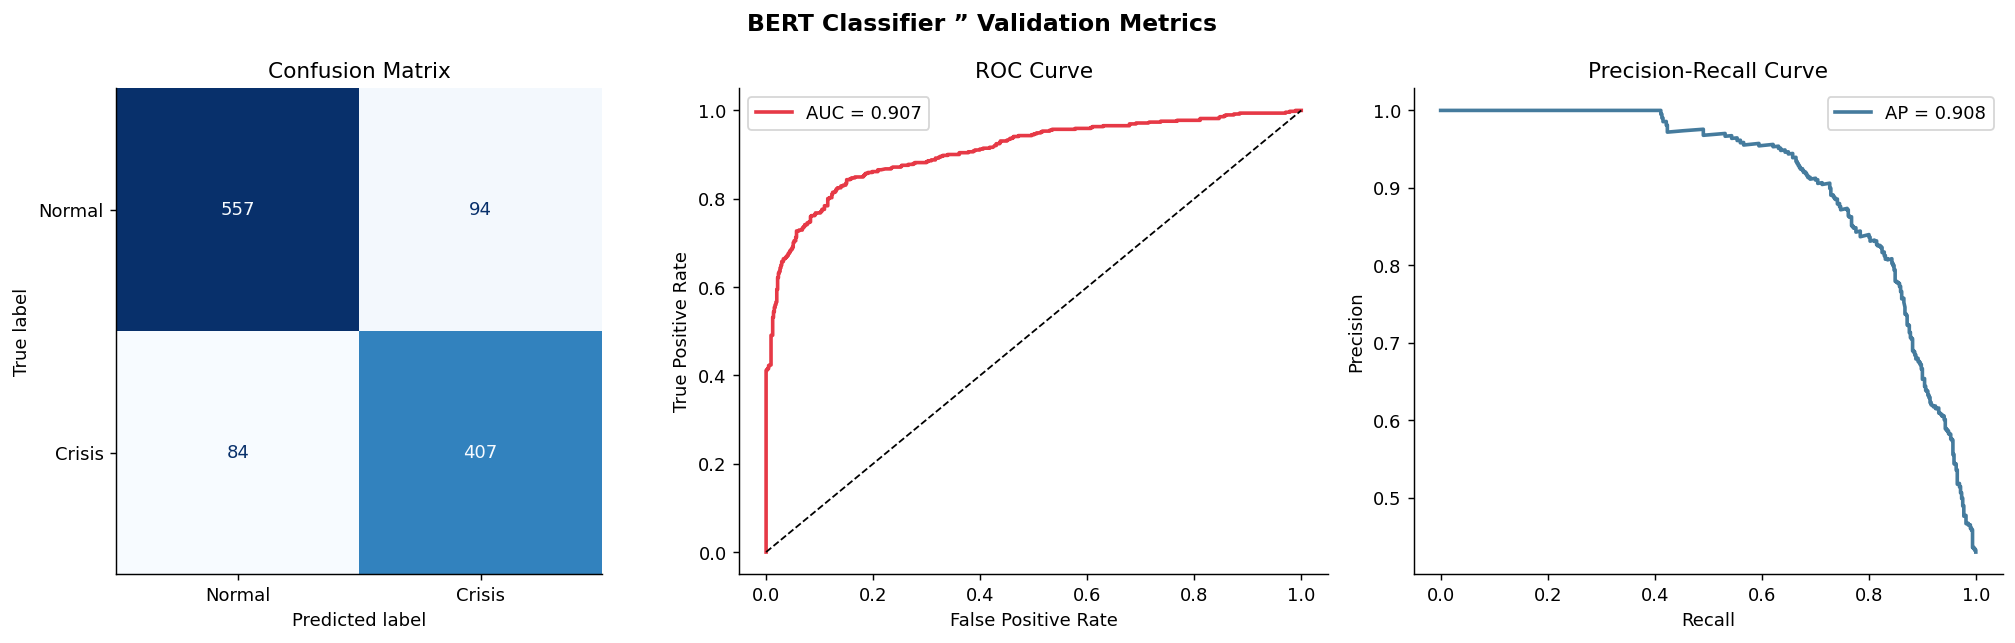

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Confusion matrix ---
cm = confusion_matrix(val_labels, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal","Crisis"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# --- ROC curve ---
fpr, tpr, _ = roc_curve(val_labels, val_scores)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color=CRISIS_COLOR, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# --- Precision-Recall curve ---
prec, rec, _ = precision_recall_curve(val_labels, val_scores)
ap = average_precision_score(val_labels, val_scores)
axes[2].plot(rec, prec, color=NORMAL_COLOR, lw=2, label=f"AP = {ap:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.suptitle("BERT Classifier ” Validation Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/charts/07_bert_validation.png", bbox_inches="tight")
plt.show()

## 4. Score Distribution

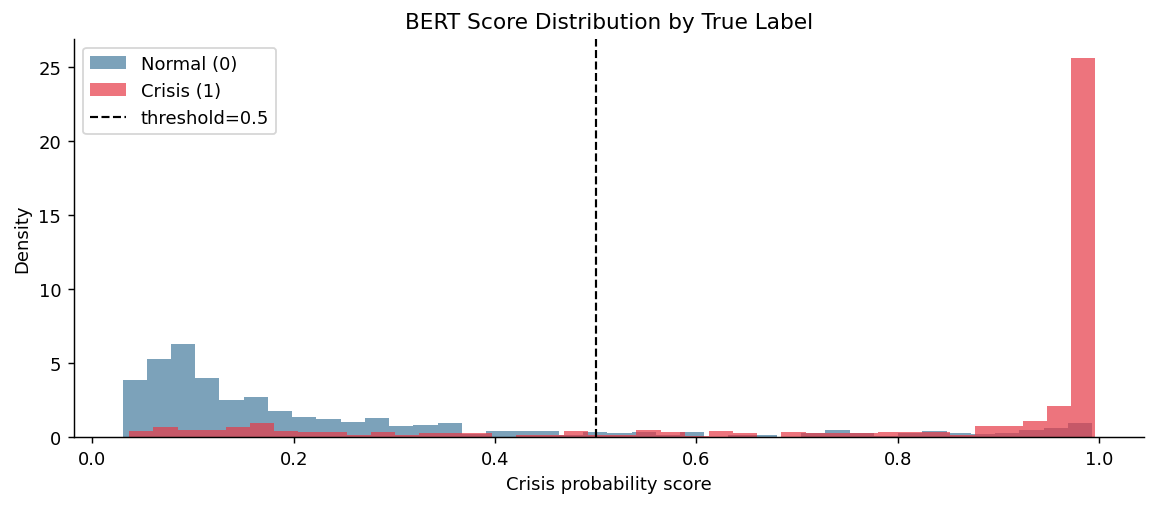

Mean crisis score  ” true crisis : 0.823
Mean crisis score  ” true normal : 0.247


In [7]:
scores_arr = np.array(val_scores)
labels_arr = np.array(val_labels)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_arr[labels_arr==0], bins=40, alpha=0.7, color=NORMAL_COLOR, label="Normal (0)", density=True)
ax.hist(scores_arr[labels_arr==1], bins=40, alpha=0.7, color=CRISIS_COLOR, label="Crisis (1)", density=True)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="threshold=0.5")
ax.set_xlabel("Crisis probability score")
ax.set_ylabel("Density")
ax.set_title("BERT Score Distribution by True Label")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/charts/08_bert_score_dist.png", bbox_inches="tight")
plt.show()

print(f"Mean crisis score  ” true crisis : {scores_arr[labels_arr==1].mean():.3f}")
print(f"Mean crisis score  ” true normal : {scores_arr[labels_arr==0].mean():.3f}")

## 5. Worst Errors ” Manual Inspection

In [8]:
results = val_df.copy().reset_index(drop=True)
results["bert_score"] = val_scores
results["pred"]       = val_preds
results["error"]      = results["pred"] != results["label"]

# False Negatives: missed crises (label=1, pred=0)
fn = results[(results["label"]==1) & (results["pred"]==0)].nsmallest(5, "bert_score")
print("=== False Negatives (missed crises) ===")
print(fn[["text_original","label","bert_score"]].to_string(index=False))

print()

# False Positives: false alarms (label=0, pred=1)
fp = results[(results["label"]==0) & (results["pred"]==1)].nlargest(5, "bert_score")
print("=== False Positives (false alarms) ===")
print(fp[["text_original","label","bert_score"]].to_string(index=False))

=== False Negatives (missed crises) ===
                                                                                                                           text_original  label  bert_score
                             Kendall Jenner and Nick Jonas Are Dating and the World Might Quite Literally Explode http://t.co/pfvzVPxQGr      1    0.036563
@leedsrouge Love what you picked! We're playing WORTH IT by FIFTH HARM/KID INK because of you! Listen &amp; Vote: http://t.co/0wrATkA2jL      1    0.040378
                        Do you feel like you are sinking in low self-image? Take the quiz: http://t.co/bJoJVM0pjX http://t.co/wHOc7LHb5F      1    0.042147
                                                                                                                  Ina Buted Girl Crush??      1    0.058050
                                             UNPREDICTABLE DISCONNECTED AND SOCIAL CASUALTY ARE MY FAVORITES HOW DO PEOPLE NOT LIKE THEM      1    0.059865

=== False Positives (fa

## 6. Save Scores for Ensemble

Persist BERT scores on the full dataset so the ensemble notebook can load them directly without re-running inference.

In [9]:
import os

full_df = pd.read_csv("../data/processed/tweets_clean.csv").dropna(subset=["text_clean"])
print(f"Scoring full dataset ({len(full_df)} tweets)...")
full_scores = clf.predict(full_df["text_clean"].tolist())
full_df["bert_score"] = full_scores

out_path = "../data/processed/tweets_bert_scores.csv"
full_df[["id","bert_score"]].to_csv(out_path, index=False)
print(f"Saved {len(full_df)} bert_scores to {out_path}")
print(full_df[["id","bert_score"]].head(3))

Scoring full dataset (7613 tweets)...
Saved 7613 bert_scores to ../data/processed/tweets_bert_scores.csv
   id  bert_score
0   1    0.978920
1   4    0.995474
2   5    0.971995
